In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Create a simple classification dataset

data = pd.DataFrame({
    "Hours_Studied": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "Exam_Score": [35, 40, 48, 52, 60, 65, 72, 78, 85, 92],
    "Passed": [0, 0, 0, 0, 1, 1, 1, 1, 1, 1]
})

data

,Hours_Studied,Exam_Score,Passed
0,1,35,0
1,2,40,0
2,3,48,0
3,4,52,0
4,5,60,1
5,6,65,1
6,7,72,1
7,8,78,1
8,9,85,1
9,10,92,1


In [3]:
X = data[["Hours_Studied", "Exam_Score"]]
y = data["Passed"]

print("Features (X):")
print(X)

print("\nTarget (y):")
print(y)

Features (X):
   Hours_Studied  Exam_Score
0              1          35
1              2          40
2              3          48
3              4          52
4              5          60
5              6          65
6              7          72
7              8          78
8              9          85
9             10          92

Target (y):
0    0
1    0
2    0
3    0
4    1
5    1
6    1
7    1
8    1
9    1
Name: Passed, dtype: int64


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (8, 2)
X_test shape: (2, 2)
y_train shape: (8,)
y_test shape: (2,)


In [5]:
model = LogisticRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Model trained successfully!
Coefficients: [[0.07894072 0.62182517]]
Intercept: [-35.15437452]


In [6]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Actual values:   ", y_test.values)
print("Predicted values:", y_pred)
print("Probabilities:   ", y_prob)

Actual values:    [0 1]
Predicted values: [0 1]
Probabilities:    [0.00624354 0.99996168]


In [7]:
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Confusion Matrix:
[[1 0]
 [0 1]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



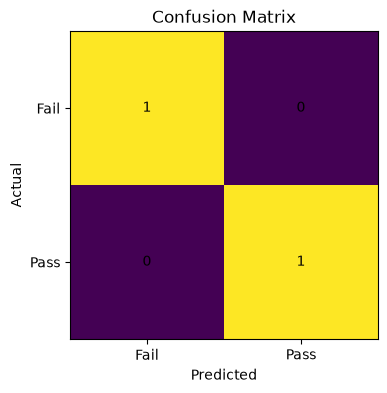

In [8]:
plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1], ["Fail", "Pass"])
plt.yticks([0, 1], ["Fail", "Pass"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

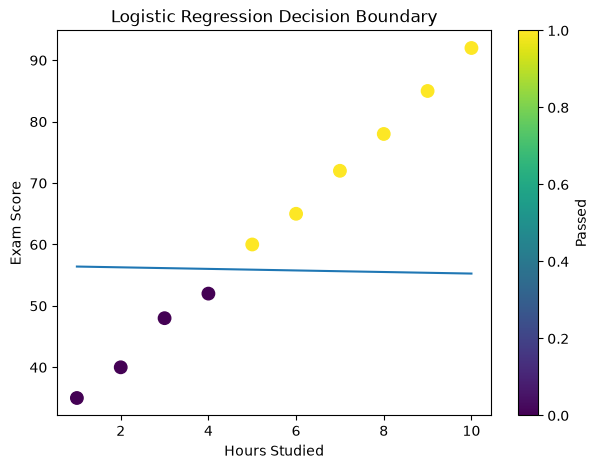

In [9]:
# Plot decision boundary

plt.figure(figsize=(7, 5))

plt.scatter(
    X["Hours_Studied"],
    X["Exam_Score"],
    c=y,
    cmap="viridis",
    s=80
)

x_values = np.linspace(X["Hours_Studied"].min(), X["Hours_Studied"].max(), 100)

b0 = model.intercept_[0]
b1 = model.coef_[0][0]
b2 = model.coef_[0][1]

y_boundary = -(b0 + b1 * x_values) / b2

plt.plot(x_values, y_boundary)

plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Logistic Regression Decision Boundary")
plt.colorbar(label="Passed")
plt.show()

In [10]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", auc)

ROC-AUC Score: 1.0
